In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# 0 - Setup

In [2]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# setting a random seed
torch.manual_seed(42)

In [4]:
!pip install datasets sentencepiece -q

In [5]:
from datasets import load_dataset

dataset = load_dataset("opus_books", "en-fr")

README.md: 0.00B [00:00, ?B/s]

en-fr/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/127085 [00:00<?, ? examples/s]

# 1 - Before the Transformer

The paper begins with a standard encoder-decoder architecture. Something like this:
> input --> Encoder --> Decoder --> Output

### Problems:
1. Cannot process all words simultaneously.

2. Long-distance dependencies are hard.

3. Training is slow.

The paper removes recurrence entirely. And proposed a transformer archictecture as follows:
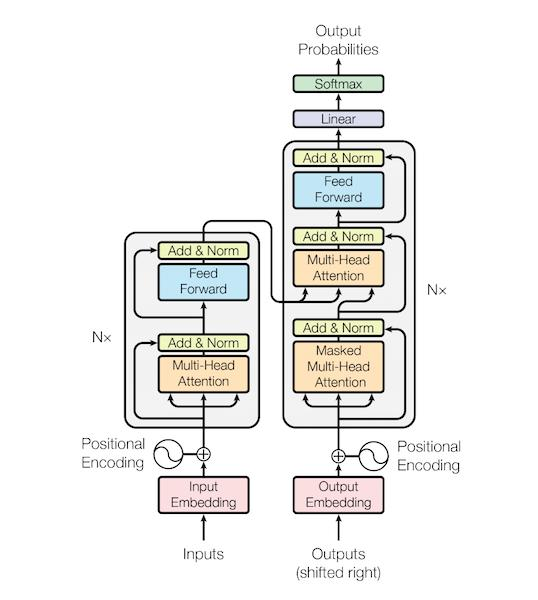

# 3 - Embeddings

The transformers never sees a word, they see vectors. So we have to embedd them into vector spaces. The paper proposed to convert each word into a 512-dimensional numric vector.

### For example:
**"I love AI"**

After tokenization:

Word    Token

I    ->   15

love ->   201

AI   ->   89


Embedding converts:
15 → [0.1, -0.7, 0.4, ...]
201 → [-0.5, 0.2, 0.9, ...]
89 → [0.8, -0.1, -0.3, ...]


In [6]:
vocab_size = 10000
d_model = 512

embedding = nn.Embedding(vocab_size, d_model)

tokens = torch.tensor([[15,201,89]])

x = embedding(tokens)

print(x.shape)

torch.Size([1, 3, 512])


## But there is one problem... Building the Transformer from Scratch

The embedding for "cat" is always the same. And transformers process all words simultaneously. So, how does it know the "I love AI" and "AI love I" are different. The answer is **Positional Embedding**.

# 3 - Positional Encoding

Instead of learning positions, the paper use sine and cosine waves. Each position receives a unique sime/cosime pattern.

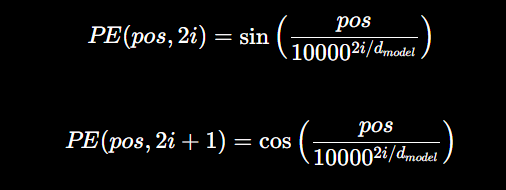

Why? cause different frequencies allow the model to infer relative positions naturally.

### Visual intuition

Imagine each dimension as a wave.



- Low-frequency waves capture broad positions.

- High-frequency waves capture fine-grained positions.

Together they create a unique signature for every position.

In [7]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0,d_model,2).float() *
            (-math.log(10000.0)/d_model)
        )

        pe[:,0::2] = torch.sin(position*div_term)
        pe[:,1::2] = torch.cos(position*div_term)

        self.register_buffer("pe",pe.unsqueeze(0))

    def forward(self,x):
        return x+self.pe[:,:x.size(1)]

In [8]:
pos_encoder = PositionalEncoding(d_model)

x = pos_encoder(x)
print(x.shape)

torch.Size([1, 3, 512])


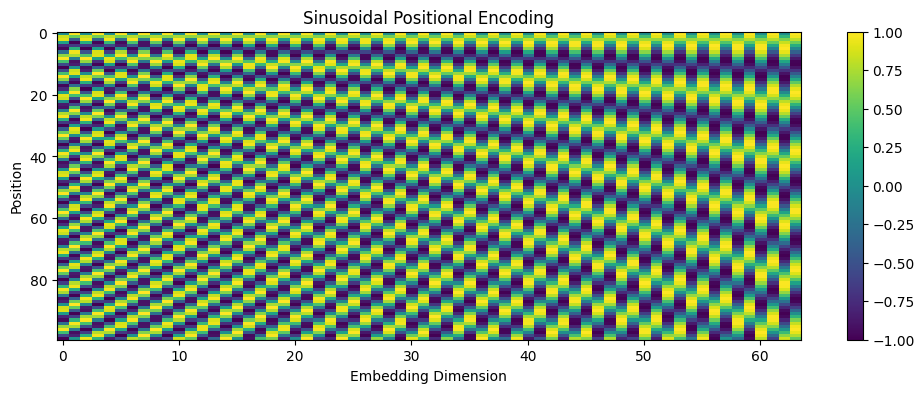

In [9]:
plt.figure(figsize=(12,4))
plt.imshow(pos_encoder.pe[0,:100,:64],aspect="auto",cmap="viridis")
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Sinusoidal Positional Encoding")
plt.colorbar()
plt.show()

# 5 - Scaled Dot-Product Attention

This is the most important equation

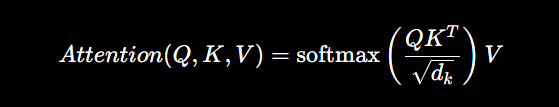

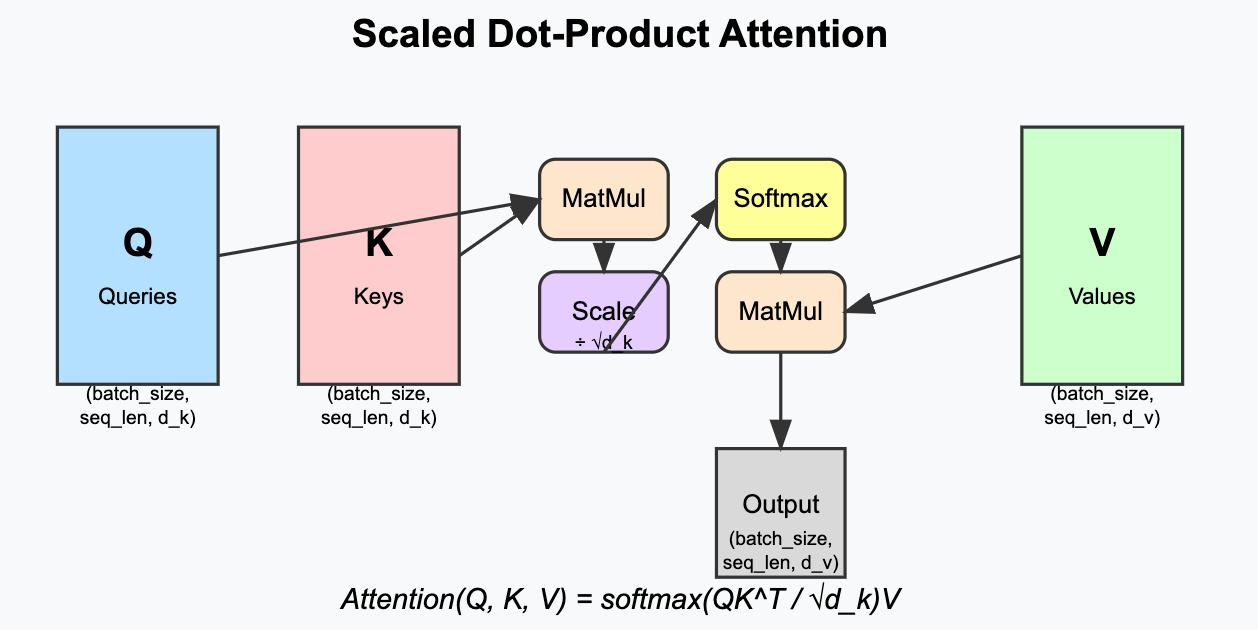

where, Q = Query, K = Key, V = Value

Think of a classroom.

Every student asks:

> "Whom should I pay attention to?"

- Query = the student's question.

- Keys = everyone else's identity.

- Values = the information each person carries.

> scores = Q @ K.transpose(-2,-1)

This produces a matrix of socres for each word associated to all the other words. Something like this:

	
            I      love    AI
    I       2.1    0.8     0.4

    love    1.5    3.2     2.8

    AI      0.2    2.0     4.1

Higher values mean stronger attention.

### Why divide by sqrt(d_k)

Without scaling:
- Large vectors produce huge dot products.

- Softmax becomes overly confident.

- Gradients become tiny.

The paper solves this by dividing by sqrt(d_k).

In [10]:
def scaled_dot_product_attention(Q,K,V,mask=None):
    d_k = Q.size(-1)

    scores = torch.matmul(Q,K.transpose(-2,-1))/math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask==0,-1e9)

    weights = torch.softmax(scores,dim=-1)

    output = torch.matmul(weights,V)

    return output,weights

In [11]:
Q = torch.randn(2,4,64)
K = torch.randn(2,4,64)
V = torch.randn(2,4,64)

out,weights = scaled_dot_product_attention(Q,K,V)

print(out.shape)
print(weights.shape)

torch.Size([2, 4, 64])
torch.Size([2, 4, 4])


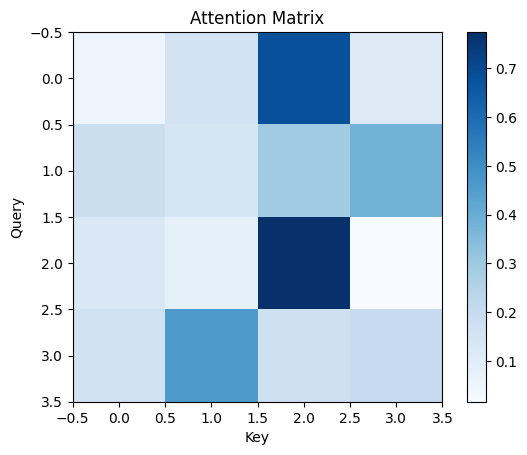

In [12]:
plt.imshow(weights[0].detach().numpy(),cmap="Blues")
plt.xlabel("Key")
plt.ylabel("Query")
plt.title("Attention Matrix")
plt.colorbar()
plt.show()

# 6 - Multi-Head Attention

One attention head learns one relationship. The paper instead uses 8 heads. 

Why? Cause different heads learn different patterns:
- grammar

- subject-verb agreement

- pronouns

- long-range dependencies

Instead of `512` we split into `64 64 64 64 64 64 64 64`, Eight parallel attention computations, and then concatenate them.

In [13]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()

        self.heads=heads
        self.d_k=d_model//heads

        self.W_q=nn.Linear(d_model,d_model)
        self.W_k=nn.Linear(d_model,d_model)
        self.W_v=nn.Linear(d_model,d_model)

        self.W_o=nn.Linear(d_model,d_model)

    def forward(self, q, k, v, mask=None):

        batch=q.size(0)

        Q=self.W_q(q)
        K=self.W_k(k)
        V=self.W_v(v)

        Q=Q.view(batch,-1,self.heads,self.d_k).transpose(1,2)
        K=K.view(batch,-1,self.heads,self.d_k).transpose(1,2)
        V=V.view(batch,-1,self.heads,self.d_k).transpose(1,2)

        out,_=scaled_dot_product_attention(Q,K,V,mask)

        out=out.transpose(1,2).contiguous()

        out=out.view(batch,-1,self.heads*self.d_k)

        return self.W_o(out)

In [14]:
mha=MultiHeadAttention(512,8)

x=torch.randn(2,5,512)

out=mha(x,x,x)

print(out.shape)

torch.Size([2, 5, 512])


# 7 - Position-wise Feed Forward Network

Every token is processed independently. The paper defines it as:

FFN(x)=max(0,xW1​+b1​)W2​+b2​

In [15]:
class FeedForward(nn.Module):

    def __init__(self,d_model,d_ff=2048):
        super().__init__()

        self.net=nn.Sequential(
            nn.Linear(d_model,d_ff),
            nn.ReLU(),
            nn.Linear(d_ff,d_model)
        )

    def forward(self,x):
        return self.net(x)

In [16]:
ffn=FeedForward(512)

out=ffn(torch.randn(2,5,512))

print(out.shape)

torch.Size([2, 5, 512])


# 8 - Encoder Layer

According to the paper, one encoder layer contains:

1. Multi-Head Self-Attention

2. Add & LayerNorm

3. Feed Forward

4. Add & LayerNorm

In [17]:
class EncoderLayer(nn.Module):
    def __init__(self,d_model=512,heads=8,d_ff=2048):
        super().__init__()

        self.attn=MultiHeadAttention(d_model,heads)
        self.ffn=FeedForward(d_model,d_ff)

        self.norm1=nn.LayerNorm(d_model)
        self.norm2=nn.LayerNorm(d_model)

    def forward(self,x):
        x=self.norm1(x+self.attn(x,x,x))

        x=self.norm2(x+self.ffn(x))

        return x

In [18]:
encoder=EncoderLayer()

x=torch.randn(2,10,512)

out=encoder(x)

print(out.shape)

torch.Size([2, 10, 512])


# 9 - Decoder Layer

The decoder has one extra attention block.

Structure:
1. Masked Self-Attention

2. Encoder-Decoder Attention

3. Feed Forward

The mask prevents future words from being visible during generation.

In [19]:
def generate_square_mask(size):
    return torch.tril(torch.ones(size,size)).bool()

In [20]:
class DecoderLayer(nn.Module):
    def __init__(self,d_model=512,heads=8,d_ff=2048):
        super().__init__()

        self.self_attn=MultiHeadAttention(d_model,heads)
        self.cross_attn=MultiHeadAttention(d_model,heads)
        self.ffn=FeedForward(d_model,d_ff)

        self.norm1=nn.LayerNorm(d_model)
        self.norm2=nn.LayerNorm(d_model)
        self.norm3=nn.LayerNorm(d_model)

    def forward(self,x,enc_out,mask=None):
        x=self.norm1(x+self.self_attn(x,x,x,mask))

        x=self.norm2(x+self.cross_attn(x,enc_out,enc_out))

        x=self.norm3(x+self.ffn(x))

        return x

In [21]:
decoder=DecoderLayer()

x=torch.randn(2,5,512)
enc=torch.randn(2,10,512)

mask=generate_square_mask(5)

out=decoder(x,enc,mask)

print(out.shape)

torch.Size([2, 5, 512])


# 10 - Mini Transformer Forward Pass

Let's verify everything works together.

In [22]:
src=torch.randn(2,8,512)
tgt=torch.randn(2,5,512)

encoder=EncoderLayer()
decoder=DecoderLayer()

enc_out=encoder(src)

mask=generate_square_mask(5)

dec_out=decoder(tgt,enc_out,mask)

print(enc_out.shape)
print(dec_out.shape)

torch.Size([2, 8, 512])
torch.Size([2, 5, 512])


# Conclusion

The paper's biggest innovation is replacing recurrence with self-attention, allowing every token to interact with every other token in a single parallel operation. The combination of sinusoidal positional encodings, scaled dot-product attention, multi-head attention, residual connections, and layer normalization forms the core architecture that later evolved into modern large language models.